# Phase 1: Data Pipeline

Fetch and process market data from NESO, Elexon, EPEX and ICE/EEX. This notebook is generated from `bess_valuation_full.ipynb` Phase 1 and can be run independently after a kernel restart.


In [1]:
import sys
from pathlib import Path

# Bootstrap imports from the project root, then use the shared helper.
_ROOT_CANDIDATE = Path.cwd()
for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
    if (candidate / "src").is_dir() and (candidate / "data").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find project root containing src/ and data/.")

from src.utils import find_project_root

PROJECT_ROOT = str(find_project_root(_ROOT_CANDIDATE))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from datetime import date
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

START = date(2024, 4, 1)   # 3 years of history for calibration
END   = date(2027, 4, 25)

RAW_DIR = Path(PROJECT_ROOT) / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f'Fetching: {START} to {END}')
print(f'Output:   {RAW_DIR}')

Fetching: 2024-04-01 to 2027-04-25
Output:   G:\My Drive\Research\bess_project\data\raw


## Step 1 — Elexon day-ahead prices (MID)

Market Index Data — volume-weighted N2EX + EPEX half-hourly index.  
Public API, no credentials required.  
**Expected**: ~35,000 rows (2 years x 365 days x 48 HH periods)

In [3]:
da_path = RAW_DIR / 'elexon_da_prices.parquet'

if da_path.exists():
    df_da = pd.read_parquet(da_path)
    print(f'Loaded cached DA prices from {da_path}')
else:
    from src.data.fetch_elexon import fetch_mid_range
    df_da = fetch_mid_range(START, END, out_path=da_path)

print(f'Rows: {len(df_da):,}')
df_da.head(8)

Loaded cached DA prices from G:\My Drive\Research\bess_project\data\raw\elexon_da_prices.parquet
Rows: 36,240


,settlement_date,settlement_period,price_gbp_mwh,volume_mwh,data_provider
0,2024-04-01,1,27.54,860.00,APXMIDP
1,2024-04-01,2,26.46,974.30,APXMIDP
2,2024-04-01,3,25.19,749.00,APXMIDP
3,2024-04-01,4,33.60,745.30,APXMIDP
4,2024-04-01,5,47.54,792.40,APXMIDP
5,2024-04-01,6,44.65,980.80,APXMIDP
6,2024-04-01,7,47.36,1325.85,APXMIDP
7,2024-04-01,8,52.94,1243.00,APXMIDP


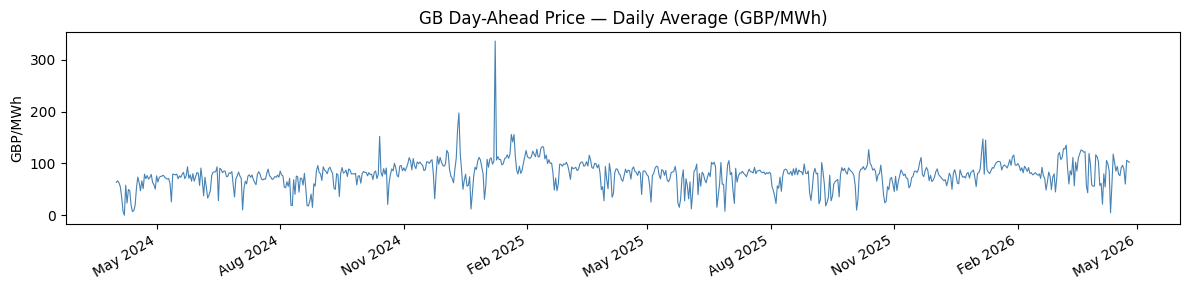

2025 DA:  mean=79.8  std=40.3  min=-102.9  max=1352.9
Negative price HHs: 1032 (model needs arithmetic OU, not log-normal)


In [4]:
if not df_da.empty:
    daily = df_da.groupby('settlement_date')['price_gbp_mwh'].mean()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(daily.index, daily.values, lw=0.8, color='steelblue')
    ax.set(title='GB Day-Ahead Price — Daily Average (GBP/MWh)', ylabel='GBP/MWh')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

    y2025 = df_da[df_da['settlement_date'].dt.year == 2025]['price_gbp_mwh']
    print(f'2025 DA:  mean={y2025.mean():.1f}  std={y2025.std():.1f}  '
          f'min={y2025.min():.1f}  max={y2025.max():.1f}')
    print(f'Negative price HHs: {(df_da["price_gbp_mwh"] < 0).sum()} '
          '(model needs arithmetic OU, not log-normal)')

## Step 2 — Elexon System Price (imbalance / cash-out)

System Price is the cash-out price for energy imbalance.  
Used to compute the DA-SP basis delta_t for OU+jump imbalance calibration.  
**Expected**: ~35,000 rows with `system_sell_price`, `system_buy_price`, `net_imbalance_volume`

In [5]:
sp_path = RAW_DIR / 'elexon_sp_prices.parquet'

if sp_path.exists():
    df_sp = pd.read_parquet(sp_path)
    print(f'Loaded cached system prices from {sp_path}')
else:
    from src.data.fetch_elexon import fetch_system_prices_range
    df_sp = fetch_system_prices_range(START, END, out_path=sp_path)

print(f'Rows: {len(df_sp):,}')
df_sp.head(6)

Loaded cached system prices from G:\My Drive\Research\bess_project\data\raw\elexon_sp_prices.parquet
Rows: 36,240


,settlement_date,settlement_period,system_sell_price,system_buy_price,net_imbalance_volume,system_price
0,2024-04-01,1,25.050000,25.050000,-339.064440,25.050000
1,2024-04-01,2,25.650000,25.650000,-230.773426,25.650000
2,2024-04-01,3,23.990000,23.990000,-66.013667,23.990000
3,2024-04-01,4,76.000000,76.000000,143.783160,76.000000
4,2024-04-01,5,73.384327,73.384327,27.688429,73.384327
5,2024-04-01,6,18.170000,18.170000,-151.031493,18.170000


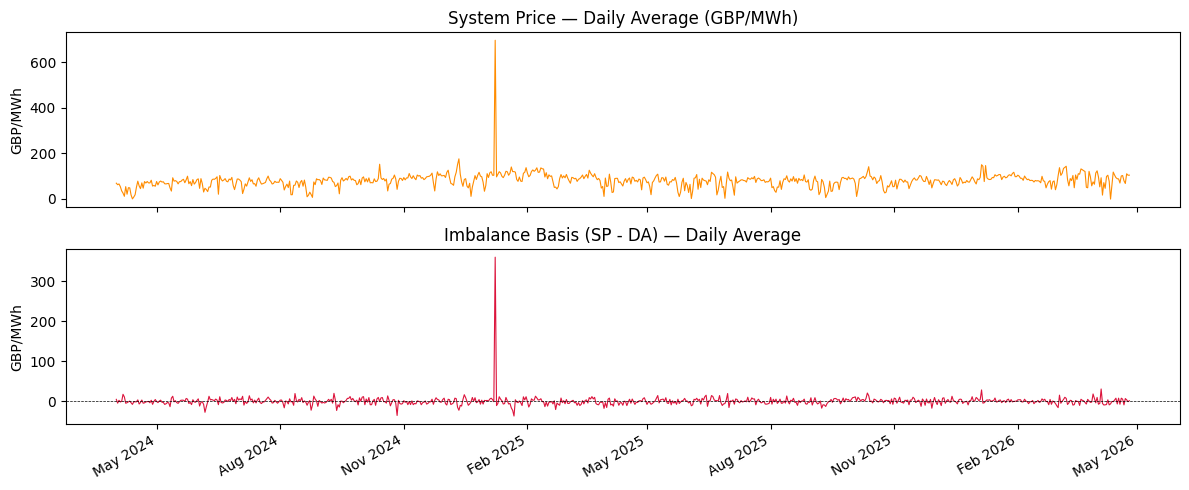

Imbalance basis stats (GBP/MWh):
count    36240.0
mean         0.2
std         39.6
min       -508.2
25%        -15.5
50%          0.0
75%         17.0
max       2028.1
Name: imbalance_basis, dtype: float64
Jump HHs (|basis|>100): 146


In [6]:
if not df_sp.empty and not df_da.empty:
    merged = df_da[['settlement_date','settlement_period','price_gbp_mwh']].merge(
        df_sp[['settlement_date','settlement_period','system_price','net_imbalance_volume']],
        on=['settlement_date','settlement_period'], how='inner'
    )
    merged['imbalance_basis'] = merged['system_price'] - merged['price_gbp_mwh']

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(merged.groupby('settlement_date')['system_price'].mean(), lw=0.8, color='darkorange')
    axes[0].set(title='System Price — Daily Average (GBP/MWh)', ylabel='GBP/MWh')
    axes[1].plot(merged.groupby('settlement_date')['imbalance_basis'].mean(), lw=0.8, color='crimson')
    axes[1].axhline(0, color='k', lw=0.5, ls='--')
    axes[1].set(title='Imbalance Basis (SP - DA) — Daily Average', ylabel='GBP/MWh')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

    print('Imbalance basis stats (GBP/MWh):')
    print(merged['imbalance_basis'].describe().round(1))
    print(f'Jump HHs (|basis|>100): {(merged["imbalance_basis"].abs()>100).sum()}')

## Step 3 — NESO EAC ancillary clearing

DC / DM / DR clearing prices by EFA block. QR from December 2024. BR from March 2024.

> **If this returns empty:** NESO reorganised dataset URLs in late 2024.  
> Go to https://api.nationalgrideso.com, search the product name (e.g. *Dynamic Containment EFA*),  
> copy the resource ID from the dataset URL, update `RESOURCE_IDS` in `src/data/fetch_neso.py`.  
> Fallback: download CSV manually, then `pd.read_csv('dc.csv').to_parquet('data/raw/neso_eac_clearing.parquet')`

In [7]:
anc_path = RAW_DIR / 'neso_eac_clearing.parquet'

if anc_path.exists():
    df_anc = pd.read_parquet(anc_path)
    print(f'Loaded cached ancillary data from {anc_path}')
else:
    from src.data.fetch_neso import fetch_all_ancillary
    df_anc = fetch_all_ancillary(START.isoformat(), END.isoformat(), out_path=anc_path)

print(f'Rows: {len(df_anc):,}')
if not df_anc.empty:
    print(df_anc.groupby('product')['clearing_price_gbp_mwh']
               .agg(['count','mean','min','max']).round(2))
else:
    print('Empty — update NESO resource IDs in src/data/fetch_neso.py')
    print('See: https://api.nationalgrideso.com')

Loaded cached ancillary data from G:\My Drive\Research\bess_project\data\raw\neso_eac_clearing.parquet
Rows: 757
         count  mean    min    max
product                           
BR         152  0.34   0.00   7.50
DC         151  1.97  -1.29   9.62
DM         151  6.24  -1.72  14.18
DR         151 -5.78 -15.14  19.25
QR         152  4.62   0.00  20.38


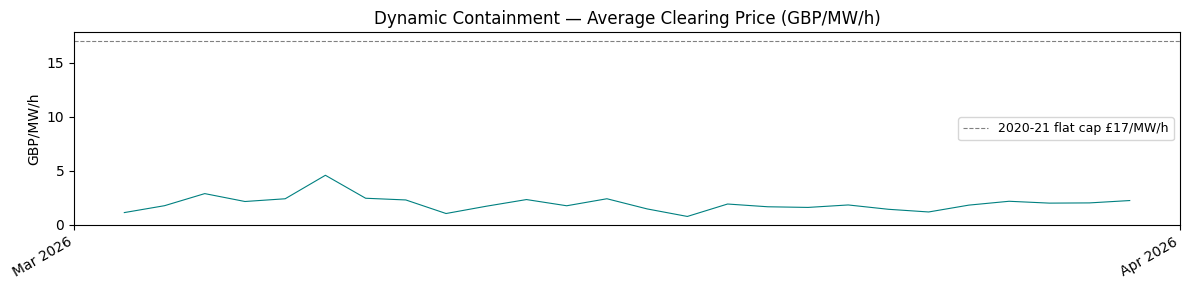

In [8]:
if not df_anc.empty and 'DC' in df_anc['product'].values:
    dc_daily = df_anc[df_anc['product']=='DC'].groupby('date')['clearing_price_gbp_mwh'].mean()
    fig, ax  = plt.subplots(figsize=(12, 3))
    ax.plot(dc_daily.index, dc_daily.values, lw=0.8, color='teal')
    ax.axhline(17, color='gray', lw=0.8, ls='--', label='2020-21 flat cap £17/MW/h')
    ax.set(title='Dynamic Containment — Average Clearing Price (GBP/MW/h)', ylabel='GBP/MW/h')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Step 4 — Forward curve

Synthetic for now, anchored to £76.7/MWh (KYOS Feb 2026 GB 10yr baseload).  

**To replace with real forwards:**  
- ICE WebICE: export GB Power monthly settlements, then run:  
  `python -m src.data.fetch_forwards --source ice --file <path>`  
- EEX transparency platform:  
  `python -m src.data.fetch_forwards --source eex --file <path>`

Synthetic forward curve:


,contract,delivery_start,price_gbp_mwh,source
0,SYN_BL_202605,2026-05-01,74.81,synthetic
1,SYN_BL_202605,2026-05-31,72.12,synthetic
2,SYN_BL_202607,2026-07-01,73.20,synthetic
3,SYN_BL_202609,2026-09-30,76.08,synthetic
4,SYN_BL_202704,2027-04-01,72.80,synthetic
5,SYN_BL_202709,2027-09-30,71.60,synthetic
6,SYN_BL_202803,2028-03-31,79.46,synthetic
7,SYN_BL_202809,2028-09-29,73.57,synthetic
8,SYN_BL_202903,2029-03-31,79.17,synthetic


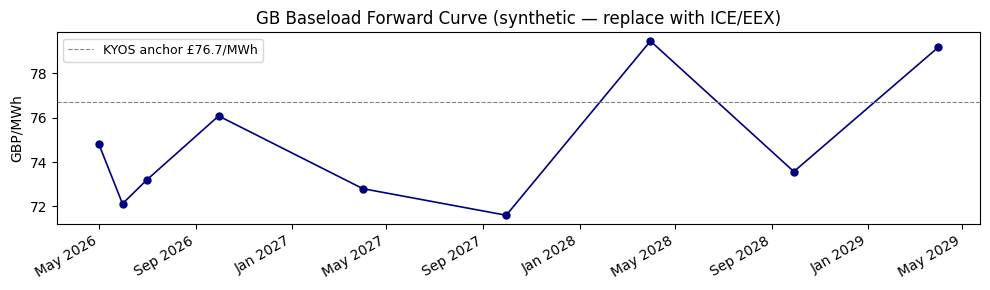

In [9]:
from src.data.fetch_forwards import build_synthetic_forwards

fwd_path = RAW_DIR / 'ice_eex_forwards.parquet'
df_fwd   = build_synthetic_forwards(as_of=df_da["settlement_date"].max().date())
df_fwd.to_parquet(fwd_path, index=False)

print('Synthetic forward curve:')
display(df_fwd[['contract','delivery_start','price_gbp_mwh','source']])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df_fwd['delivery_start'], df_fwd['price_gbp_mwh'], 'o-', color='navy', ms=5, lw=1.2)
ax.axhline(76.7, color='gray', lw=0.8, ls='--', label='KYOS anchor £76.7/MWh')
ax.set(title='GB Baseload Forward Curve (synthetic — replace with ICE/EEX)', ylabel='GBP/MWh')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Validation Summary

In [10]:
print('=' * 55)
print('PHASE 1 VALIDATION SUMMARY')
print('=' * 55)

checks = {
    'elexon_da_prices.parquet':  100,
    'elexon_sp_prices.parquet':  100,
    'neso_eac_clearing.parquet':   0,
    'ice_eex_forwards.parquet':    1,
}

all_ok = True
for name, min_rows in checks.items():
    path = RAW_DIR / name
    if path.exists():
        n   = len(pd.read_parquet(path))
        ok  = n >= min_rows
        sym = 'OK  ' if ok else 'WARN'
        print(f'  [{sym}]  {name}: {n:,} rows')
        if not ok: all_ok = False
    else:
        print(f'  [FAIL]  {name}: MISSING'); all_ok = False

# Calibration spot-check
da_file = RAW_DIR / 'elexon_da_prices.parquet'
if da_file.exists():
    df_chk = pd.read_parquet(da_file)
    if not df_chk.empty:
        m25 = df_chk[df_chk['settlement_date'].dt.year==2025]['price_gbp_mwh'].mean()
        neg = (df_chk['price_gbp_mwh'] < 0).sum()
        print(f'\n  DA mean 2025:  £{m25:.1f}/MWh  (SS anchor: £76.7)')
        print(f'  Negative HHs:  {neg}  (arithmetic OU required, not log-normal)')

print('\nRESULT:', 'All files present — ready for Phase 2 calibration'
      if all_ok else 'Some files missing — see notes above')
print('Next: notebooks/02_calibration.ipynb')

PHASE 1 VALIDATION SUMMARY
  [OK  ]  elexon_da_prices.parquet: 36,240 rows
  [OK  ]  elexon_sp_prices.parquet: 36,240 rows
  [OK  ]  neso_eac_clearing.parquet: 757 rows
  [OK  ]  ice_eex_forwards.parquet: 9 rows

  DA mean 2025:  £79.8/MWh  (SS anchor: £76.7)
  Negative HHs:  1032  (arithmetic OU required, not log-normal)

RESULT: All files present — ready for Phase 2 calibration
Next: notebooks/02_calibration.ipynb
